Inline backend: module://matplotlib_inline.backend_inline

Shape: (506, 14)
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  
Class distribution:
 price_class
Medium    280
High      132
Low        94
Name: count, dtype: int64


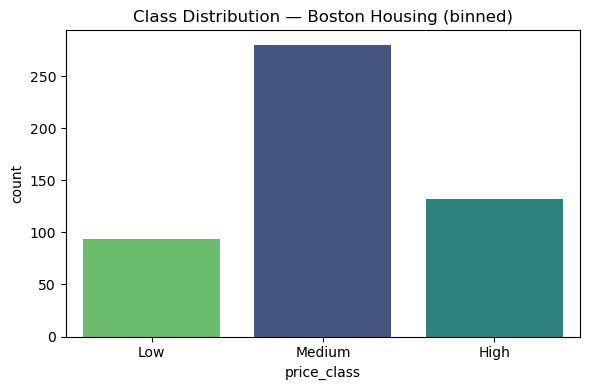


Train shape: (404, 13)
Test shape : (102, 13)

=== BASELINE RANDOM FOREST ===
Train accuracy : 1.0
Test  accuracy : 0.8235
Test  F1 (wtd) : 0.8226
Fitting 5 folds for each of 120 candidates, totalling 600 fits

=== BEST PARAMETERS ===
{'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 50}
Best CV F1 (weighted): 0.8682

=== TUNED RANDOM FOREST ===
Train accuracy : 0.9752
Test  accuracy : 0.7941
Precision      : 0.7973
Recall         : 0.7941
F1 (weighted)  : 0.7933

Classification Report:
              precision    recall  f1-score   support

         Low       0.87      0.68      0.76        19
      Medium       0.80      0.84      0.82        56
        High       0.75      0.78      0.76        27

    accuracy                           0.79       102
   macro avg       0.80      0.77      0.78       102
weighted avg       0.80      0.79      0.79       102

5-fold CV accuracy scores: [0.9136 0.8519 0.8765 0.8519 0.85  ]
Mean CV accuracy         : 0.868

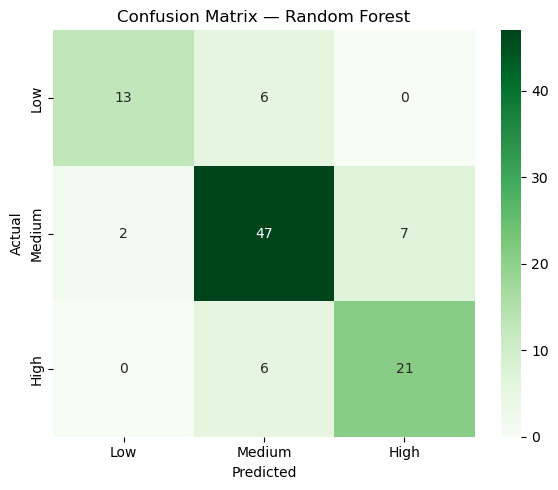

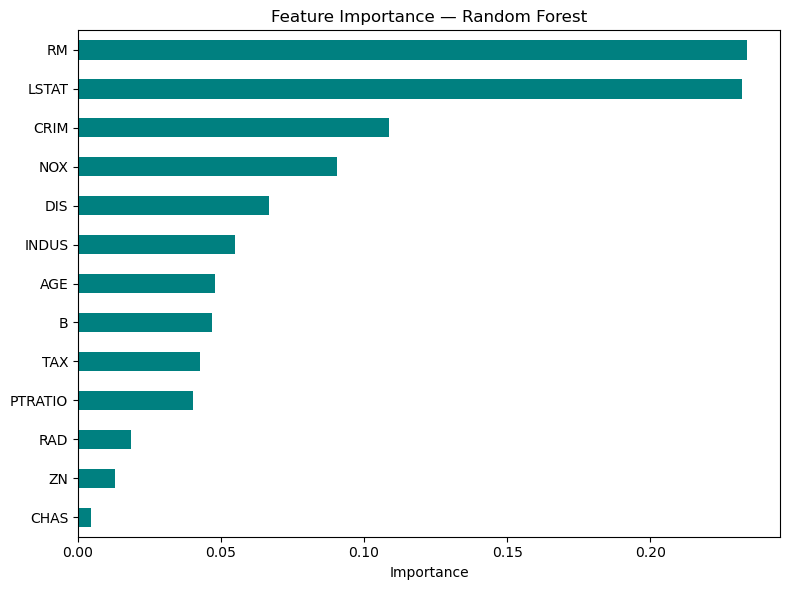

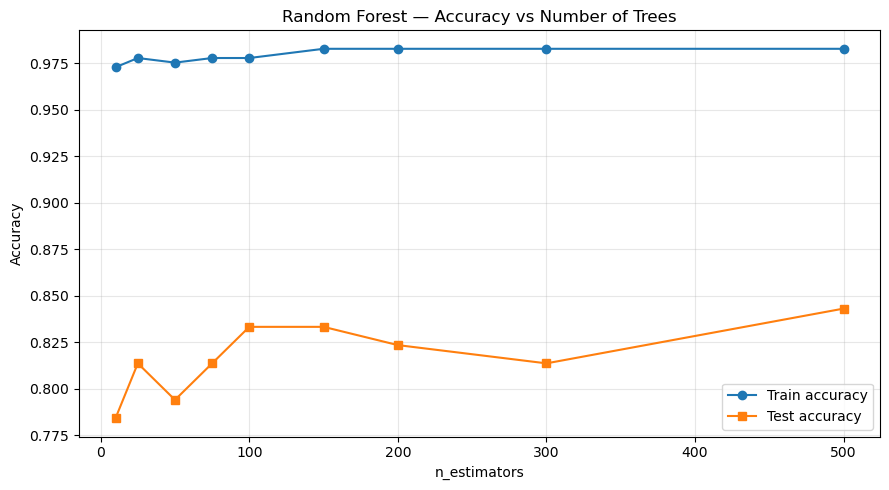


Saved images: ['class_distribution_rf.png', 'confusion_matrix_rf.png', 'feature_importance_rf.png', 'rf_n_estimators.png']


In [1]:
# =========================================================
# Random Forest Classifier — Boston Housing (Level 3, Task 1)
# Codveda ML Internship — Single-Cell Version
# =========================================================
%matplotlib inline

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# ---------------------------------------------------------
# 0. Output folder
# ---------------------------------------------------------
os.makedirs("images", exist_ok=True)
print("Inline backend:", plt.get_backend())

# ---------------------------------------------------------
# 1. Load Boston Housing dataset (no header, whitespace-separated)
# ---------------------------------------------------------
path = r"C:\Users\250 G7\Desktop\CodeVeda Intern\Dataset\4) house Prediction Data Set.csv"

df = pd.read_csv(path, header=None, sep=r"\s+", engine="python")
df.columns = [
    "CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE",
    "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT", "MEDV"
]

print("\nShape:", df.shape)
print(df.head())

# ---------------------------------------------------------
# 3. Bin MEDV into 3 classes
# ---------------------------------------------------------
def bin_medv(v):
    if v < 15:
        return "Low"
    elif v < 25:
        return "Medium"
    else:
        return "High"

df["price_class"] = df["MEDV"].apply(bin_medv)
class_order = ["Low", "Medium", "High"]
df["price_class_encoded"] = df["price_class"].map(
    {c: i for i, c in enumerate(class_order)}
)

print("Class distribution:\n", df["price_class"].value_counts())

# ---- Class distribution plot (fixed to avoid FutureWarning) ----
plt.figure(figsize=(6, 4))
sns.countplot(
    x="price_class",
    data=df,
    order=class_order,
    palette="viridis",
    hue="price_class",
    legend=False,
)
plt.title("Class Distribution — Boston Housing (binned)")
plt.tight_layout()
plt.savefig("images/class_distribution_rf.png", dpi=150, bbox_inches="tight")
plt.show()


# ---------------------------------------------------------
# 3. Features + target + split
# ---------------------------------------------------------
feature_cols = [c for c in df.columns if c not in
                ["MEDV", "price_class", "price_class_encoded"]]
X = df[feature_cols]
y = df["price_class_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("\nTrain shape:", X_train.shape)
print("Test shape :", X_test.shape)

# ---------------------------------------------------------
# 4. Baseline Random Forest
# ---------------------------------------------------------
rf_baseline = RandomForestClassifier(random_state=42)
rf_baseline.fit(X_train, y_train)
y_pred_base = rf_baseline.predict(X_test)

print("\n=== BASELINE RANDOM FOREST ===")
print("Train accuracy :", round(accuracy_score(y_train, rf_baseline.predict(X_train)), 4))
print("Test  accuracy :", round(accuracy_score(y_test, y_pred_base), 4))
print("Test  F1 (wtd) :", round(f1_score(y_test, y_pred_base, average="weighted"), 4))

# ---------------------------------------------------------
# 5. Hyperparameter tuning with GridSearchCV
# ---------------------------------------------------------
param_grid = {
    "n_estimators": [50, 100, 200, 300],
    "max_depth": [None, 4, 6, 8, 12],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1,
)
grid.fit(X_train, y_train)

print("\n=== BEST PARAMETERS ===")
print(grid.best_params_)
print("Best CV F1 (weighted):", round(grid.best_score_, 4))

best_rf = grid.best_estimator_

# ---------------------------------------------------------
# 6. Evaluate tuned model
# ---------------------------------------------------------
y_pred_best = best_rf.predict(X_test)

print("\n=== TUNED RANDOM FOREST ===")
print("Train accuracy :", round(accuracy_score(y_train, best_rf.predict(X_train)), 4))
print("Test  accuracy :", round(accuracy_score(y_test, y_pred_best), 4))
print("Precision      :", round(precision_score(y_test, y_pred_best, average="weighted"), 4))
print("Recall         :", round(recall_score(y_test, y_pred_best, average="weighted"), 4))
print("F1 (weighted)  :", round(f1_score(y_test, y_pred_best, average="weighted"), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=class_order))

# ---------------------------------------------------------
# 7. Cross-validation scores
# ---------------------------------------------------------
cv_scores = cross_val_score(
    best_rf, X_train, y_train,
    cv=cv, scoring="accuracy"
)
print("5-fold CV accuracy scores:", np.round(cv_scores, 4))
print("Mean CV accuracy         :", round(cv_scores.mean(), 4))
print("Std  CV accuracy         :", round(cv_scores.std(), 4))

# ---------------------------------------------------------
# 8. Confusion matrix
# ---------------------------------------------------------
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=class_order, yticklabels=class_order)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Random Forest")
plt.tight_layout()
plt.savefig("images/confusion_matrix_rf.png", dpi=150, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------
# 9. Feature importance
# ---------------------------------------------------------
importances = pd.Series(
    best_rf.feature_importances_, index=feature_cols
).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importances.plot(kind="barh", color="teal")
plt.title("Feature Importance — Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("images/feature_importance_rf.png", dpi=150, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------
# 10. Effect of n_estimators on accuracy
# ---------------------------------------------------------
n_range = [10, 25, 50, 75, 100, 150, 200, 300, 500]
train_scores = []
test_scores = []

for n in n_range:
    rf = RandomForestClassifier(
        n_estimators=n,
        max_depth=best_rf.max_depth,
        min_samples_leaf=best_rf.min_samples_leaf,
        max_features=best_rf.max_features,
        random_state=42,
        n_jobs=-1,
    )
    rf.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, rf.predict(X_train)))
    test_scores.append(accuracy_score(y_test, rf.predict(X_test)))

plt.figure(figsize=(9, 5))
plt.plot(n_range, train_scores, marker="o", label="Train accuracy")
plt.plot(n_range, test_scores, marker="s", label="Test accuracy")
plt.xlabel("n_estimators")
plt.ylabel("Accuracy")
plt.title("Random Forest — Accuracy vs Number of Trees")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("images/rf_n_estimators.png", dpi=150, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------
# 11. Verify saved images
# ---------------------------------------------------------
print("\nSaved images:", sorted(os.listdir("images")))